<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/friedmann_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Friedmann equations**

Study cosmology using the Friedmann equations and plot the expansion of the universe. Friedmann equation is given as:

$
H^2(t) = \frac{8 \pi G}{3} \rho - \frac{k c^2}{R^2} + \frac{\Lambda c^2}{3}
$

Where:
- \( H(t) \) is the Hubble parameter.
- \( G \) is the gravitational constant.
- \( \rho \) is the density of matter and energy in the universe.
- \( k \) is the curvature (k = -1, 0, +1 for open, flat, and closed universes).
- \( \Lambda \) is the cosmological constant.
- \( R \) is the scale factor (describes the expansion of the universe).

For simplicity, we’ll assume a flat universe with \( k = 0 \), which simplifies the Friedmann equation.

This models the expansion of the universe by solving the simplified Friedmann equation for a flat universe, using some typical cosmological parameters:

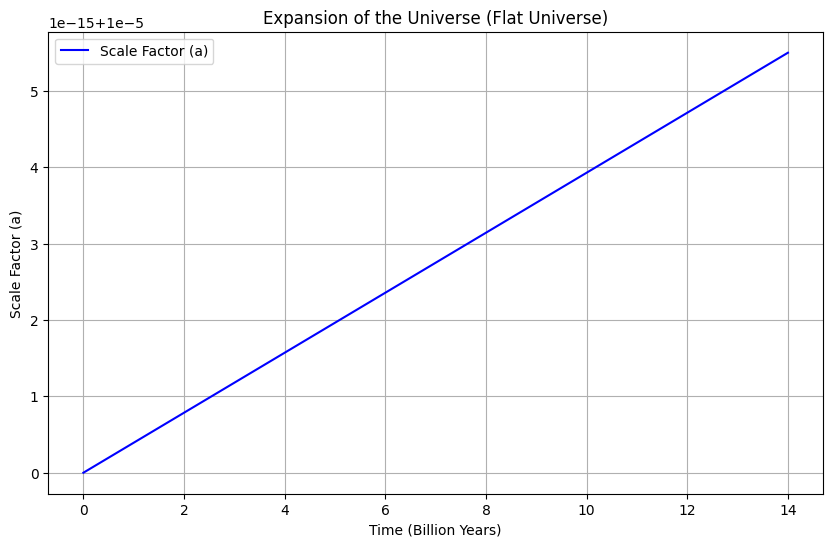

In [ ]:
!pip install matplotlib -q
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Cosmological constants
H0 = 70  # Hubble constant today in km/s/Mpc
Omega_m = 0.3  # Matter density parameter
Omega_lambda = 0.7  # Dark energy density parameter
c = 3e5  # Speed of light in km/s

# Convert H0 from km/s/Mpc to s^-1
H0_s = H0 / (3.086e19)

# Friedmann equation for a flat universe (k = 0)
def friedmann_eq(t, a):
    # da/dt = a * H(a)
    return H0_s * np.sqrt(Omega_m / a**3 + Omega_lambda) * a

# Time range in billions of years
time = np.linspace(0, 14, 1000)  # From 0 to 14 billion years

# Solving Friedmann equation (expansion factor)
a0 = 1e-5  # Initial scale factor (early universe)
sol = solve_ivp(friedmann_eq, [0, 14], [a0], t_eval=time)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time, sol.y[0], label='Scale Factor (a)', color='b')
plt.title('Expansion of the Universe (Flat Universe)')
plt.xlabel('Time (Billion Years)')
plt.ylabel('Scale Factor (a)')
plt.grid(True)
plt.legend()
plt.show()


- We use `solve_ivp` from `scipy` to numerically integrate the Friedmann equation and obtain the evolution of the scale factor \( a(t) \) over time.
- The parameters \( \Omega_m \) and \( \Omega_\lambda \) represent the fractions of the universe's energy density in matter and dark energy, respectively.
- The initial scale factor \( a_0 \) is very small, corresponding to the early universe.

This code simulates how the scale factor of the universe changes over time, which tells us how the universe expands. A flat universe will show increasing expansion due to dark energy (cosmological constant).

If you want to dive deeper into cosmology, you could extend this to include radiation density and different curvature models (open or closed universes).

**We’ll extend the previous code to include radiation density and curvature models for open, flat, and closed universes.**

The general Friedmann equation is:

$
H^2(t) = H_0^2 \left( \Omega_m a^{-3} + \Omega_r a^{-4} + \Omega_k a^{-2} + \Omega_\Lambda \right)
$

Where:
- \( \Omega_m \): Matter density parameter.
- \( \Omega_r \): Radiation density parameter.
- \( \Omega_k \): Curvature density parameter.
- \( \Omega_\Lambda \): Dark energy (cosmological constant).
- \( a \): Scale factor.

For different curvature models:
- \( \Omega_k = 1 - (\Omega_m + \Omega_r + \Omega_\Lambda) \), where:
  - \( \Omega_k < 0 \) for a closed universe.
  - \( \Omega_k = 0 \) for a flat universe.
  - \( \Omega_k > 0 \) for an open universe.

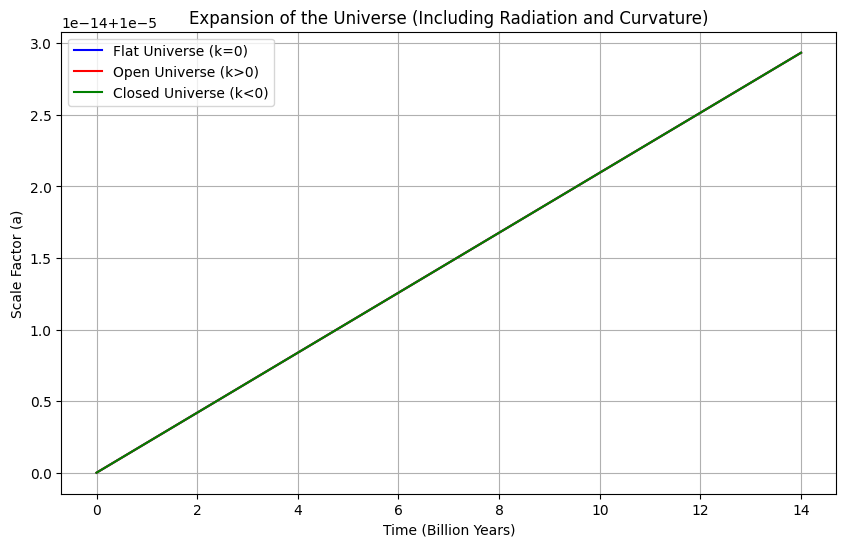

In [ ]:
!pip install matplotlib -q
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Cosmological constants
H0 = 70  # Hubble constant today in km/s/Mpc
Omega_m = 0.3  # Matter density parameter
Omega_r = 8.24e-5  # Radiation density parameter (small, but non-zero)
Omega_Lambda = 0.7  # Dark energy density parameter
c = 3e5  # Speed of light in km/s

# Compute curvature parameter for different curvature models
# For a flat universe: Omega_k = 0
# For an open universe: Omega_k > 0
# For a closed universe: Omega_k < 0
Omega_k_flat = 1 - (Omega_m + Omega_r + Omega_Lambda)  # Should be 0
Omega_k_open = 0.1  # Example for open universe
Omega_k_closed = -0.1  # Example for closed universe

# Convert H0 from km/s/Mpc to s^-1
H0_s = H0 / (3.086e19)

# Generalized Friedmann equation including curvature and radiation
def friedmann_eq(t, a, Omega_k):
    # da/dt = a * H(a)
    return H0_s * np.sqrt(Omega_m / a**3 + Omega_r / a**4 + Omega_k / a**2 + Omega_Lambda) * a

# Time range in billions of years
time = np.linspace(0, 14, 1000)  # From 0 to 14 billion years

# Initial scale factor (early universe)
a0 = 1e-5

# Solve for a flat universe
sol_flat = solve_ivp(friedmann_eq, [0, 14], [a0], t_eval=time, args=(Omega_k_flat,))

# Solve for an open universe
sol_open = solve_ivp(friedmann_eq, [0, 14], [a0], t_eval=time, args=(Omega_k_open,))

# Solve for a closed universe
sol_closed = solve_ivp(friedmann_eq, [0, 14], [a0], t_eval=time, args=(Omega_k_closed,))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time, sol_flat.y[0], label='Flat Universe (k=0)', color='b')
plt.plot(time, sol_open.y[0], label='Open Universe (k>0)', color='r')
plt.plot(time, sol_closed.y[0], label='Closed Universe (k<0)', color='g')
plt.title('Expansion of the Universe (Including Radiation and Curvature)')
plt.xlabel('Time (Billion Years)')
plt.ylabel('Scale Factor (a)')
plt.grid(True)
plt.legend()
plt.show()

1. **Radiation Density (\( \Omega_r \))**:
   - Included the term \( \Omega_r a^{-4} \) to account for radiation in the Friedmann equation.
   
2. **Curvature (\( \Omega_k \))**:
   - Added a curvature term \( \Omega_k a^{-2} \) to model open (\( \Omega_k > 0 \)) and closed (\( \Omega_k < 0 \)) universes.
   
3. **Different Universe Models**:
   - I’ve provided solutions for three different universes:
     - **Flat universe**: \( \Omega_k = 0 \)
     - **Open universe**: Example with \( \Omega_k = 0.1 \)
     - **Closed universe**: Example with \( \Omega_k = -0.1 \)

- The scale factor evolution \( a(t) \) is calculated for each curvature model (flat, open, closed) using the generalized Friedmann equation.
- This allows you to compare the expansion history of different universe geometries under the influence of matter, radiation, and dark energy.